In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from main import *


In [49]:

project_root = "U:/ML_project/bargh"

csv_read_path = os.path.join(project_root, "data", "processed", "integrated.csv")
df = pd.read_csv(csv_read_path, encoding='utf-8')


In [50]:
condition = (df['status'] != 'FO') & (df['status'] != 'LF1')
df.loc[condition, 'status'] = "NOT"


In [51]:
df.columns

Index(['id', 'name', 'code', 'date', 'hour', 'temperature', 'humidity', 'dew',
       'apparent_temperature', 'precipitation', 'rain', 'snow',
       'surface_pressure', 'evapotransporation', 'wind_speed',
       'wind_direction', 'value', 'forecast', 'generation', 'declare',
       'status', 'require'],
      dtype='object')

In [59]:
feature_adder = Feature_adder(df, add_label_column=False)
for hour in range(1, 25):
    feature_adder.create_feature_with_delay("status", hour)
df = feature_adder.df

In [60]:
df.columns

Index(['id', 'name', 'code', 'date', 'hour', 'temperature', 'humidity', 'dew',
       'apparent_temperature', 'precipitation', 'rain', 'snow',
       'surface_pressure', 'evapotransporation', 'wind_speed',
       'wind_direction', 'value', 'forecast', 'generation', 'declare',
       'status', 'require', 'season', 'datetime', 'status_with_1_delay',
       'status_with_2_delay', 'status_with_3_delay', 'status_with_4_delay',
       'status_with_5_delay', 'status_with_6_delay', 'status_with_7_delay',
       'status_with_8_delay', 'status_with_9_delay', 'status_with_10_delay',
       'status_with_11_delay', 'status_with_12_delay', 'status_with_13_delay',
       'status_with_14_delay', 'status_with_15_delay', 'status_with_16_delay',
       'status_with_17_delay', 'status_with_18_delay', 'status_with_19_delay',
       'status_with_20_delay', 'status_with_21_delay', 'status_with_22_delay',
       'status_with_23_delay', 'status_with_24_delay'],
      dtype='object')

In [61]:
feature_selector = Feature_selector(df, 'status')
features_to_drop = ['id', 'date', 'apparent_temperature', 'generation', 'datetime']
feature_selector.select(features_to_drop=features_to_drop)
features_to_select = ['name', 'code', 'hour', 'temperature', 'value', 'forecast', 'declare', 'require', 'season']
for hour in range(1, 25):
    features_to_select.append(f"status_with_{hour}_delay")
feature_selector.select(features_to_select=features_to_select)
df_modified = feature_selector.df

In [62]:
df_bad1 = df_modified[(df_modified['status'] == "FO")]
df_bad2 = df_modified[(df_modified['status'] == "LF1")]

def compare_feature(column_name, bins):
    column_bad1 = df_bad1[column_name].values
    column_bad2 = df_bad2[column_name].values
    column = df[column_name].values
    plt.figure(figsize=(15, 8))
    plt.hist(column_bad1, label="bad1", alpha=0.5, density=True, bins=bins, color="#0072B2")
    plt.hist(column_bad2, label="bad2", alpha=0.5, density=True, bins=bins, color="#E69F00")
    plt.hist(column, label="all", alpha=0.5, density=True, bins=bins, color='#D55E00')
    plt.title(column_name)
    plt.legend()
    plt.show()


df_modified.columns

Index(['name', 'code', 'hour', 'temperature', 'value', 'forecast', 'declare',
       'require', 'season', 'status_with_1_delay', 'status_with_2_delay',
       'status_with_3_delay', 'status_with_4_delay', 'status_with_5_delay',
       'status_with_6_delay', 'status_with_7_delay', 'status_with_8_delay',
       'status_with_9_delay', 'status_with_10_delay', 'status_with_11_delay',
       'status_with_12_delay', 'status_with_13_delay', 'status_with_14_delay',
       'status_with_15_delay', 'status_with_16_delay', 'status_with_17_delay',
       'status_with_18_delay', 'status_with_19_delay', 'status_with_20_delay',
       'status_with_21_delay', 'status_with_22_delay', 'status_with_23_delay',
       'status_with_24_delay', 'status'],
      dtype='object')

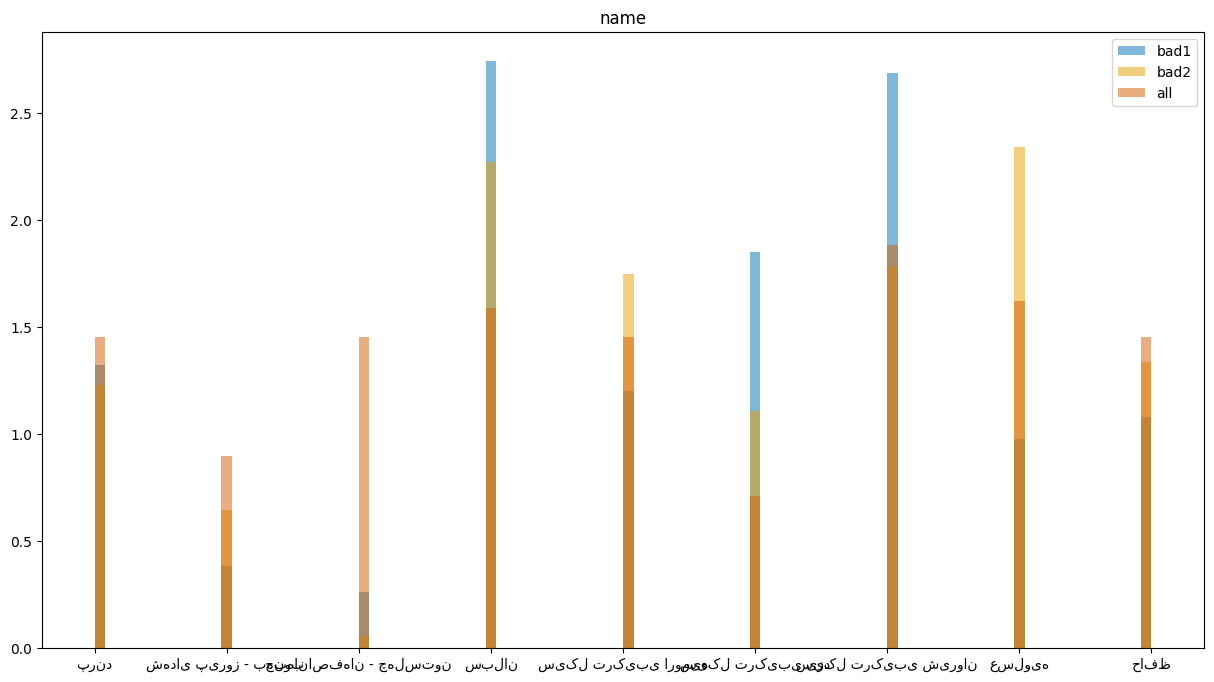

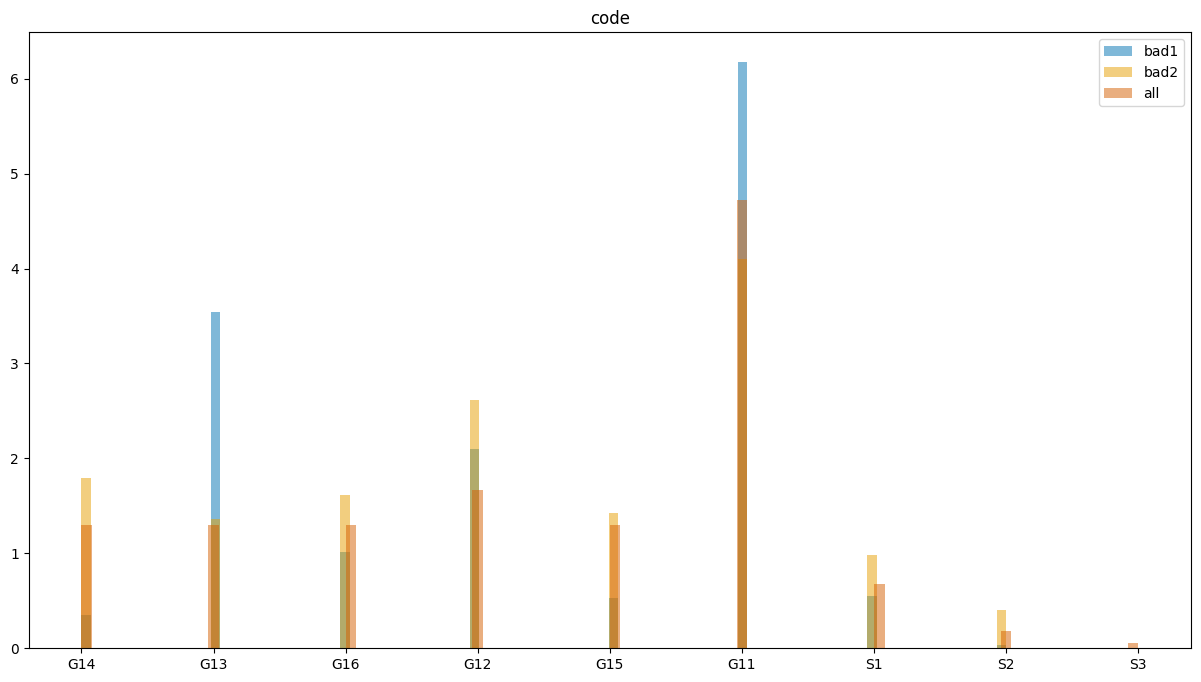

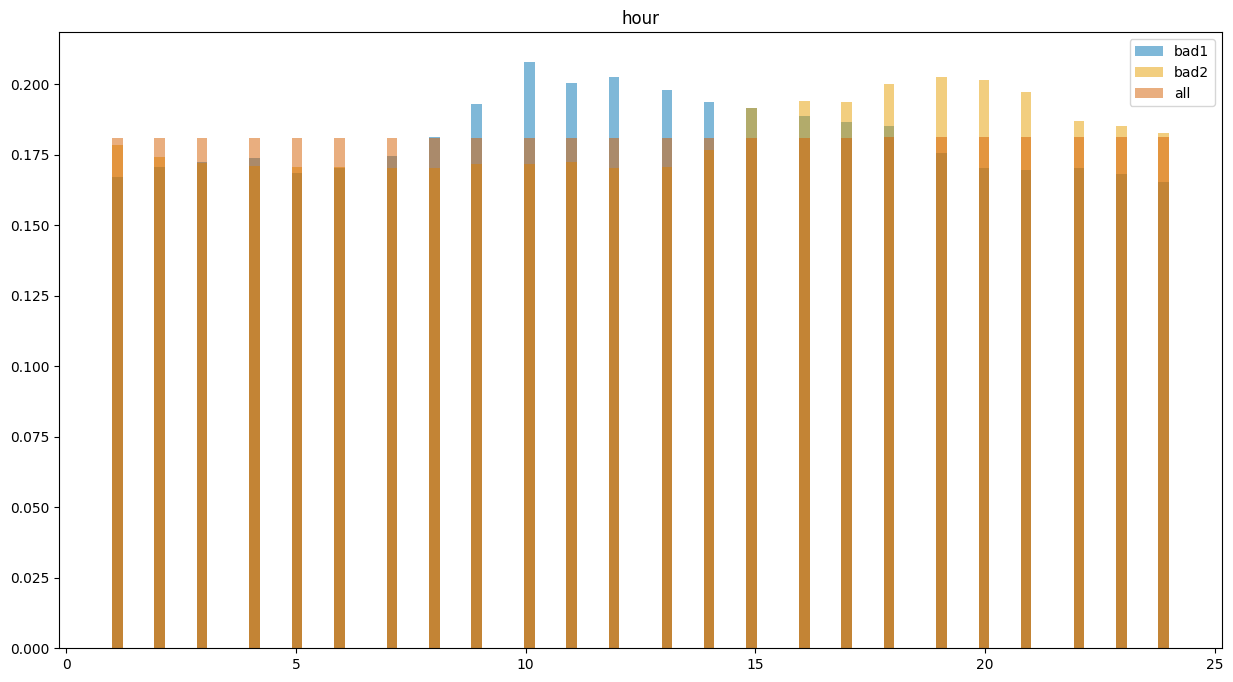

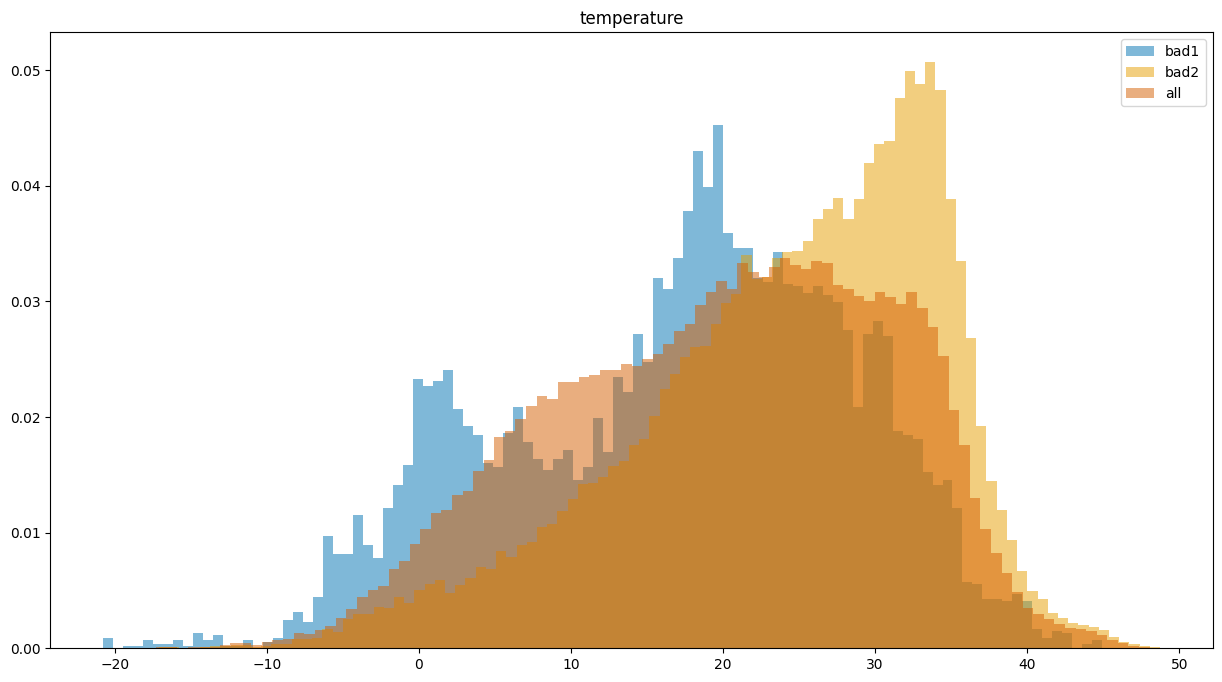

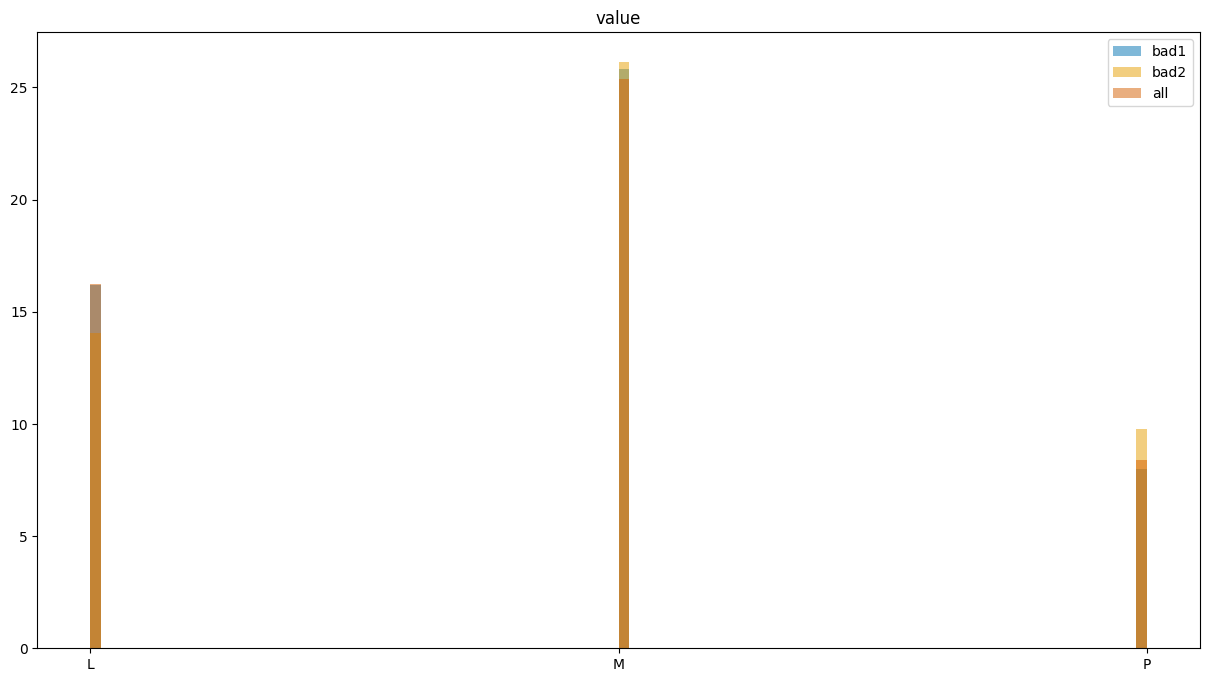

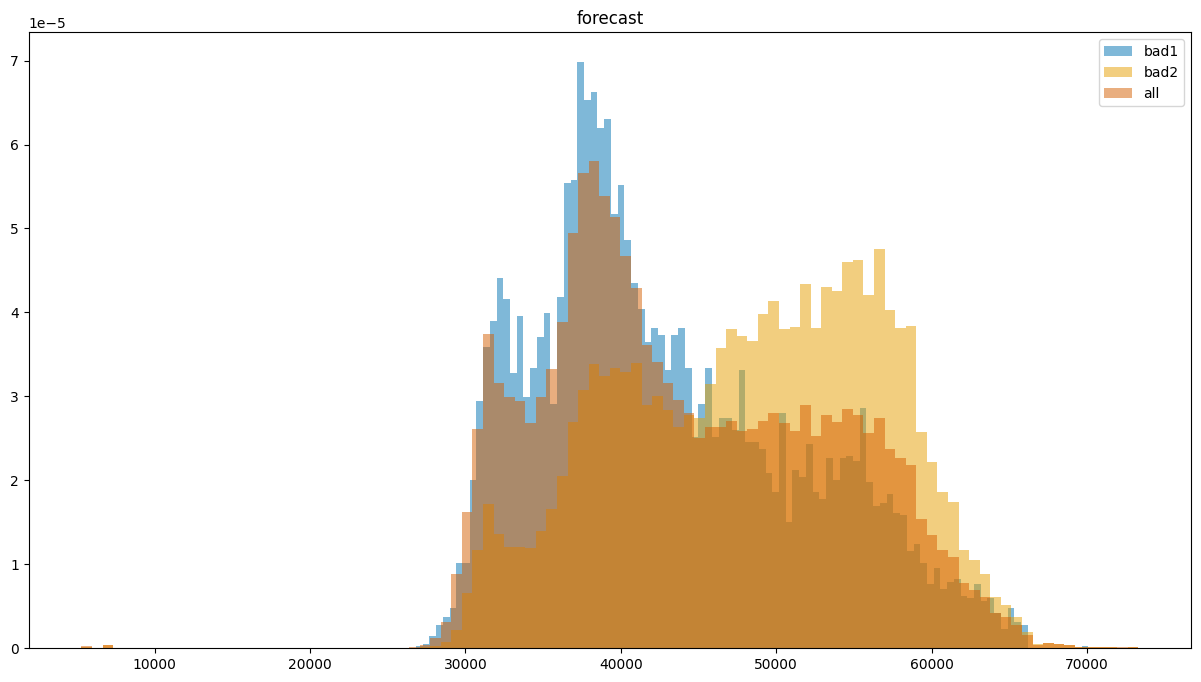

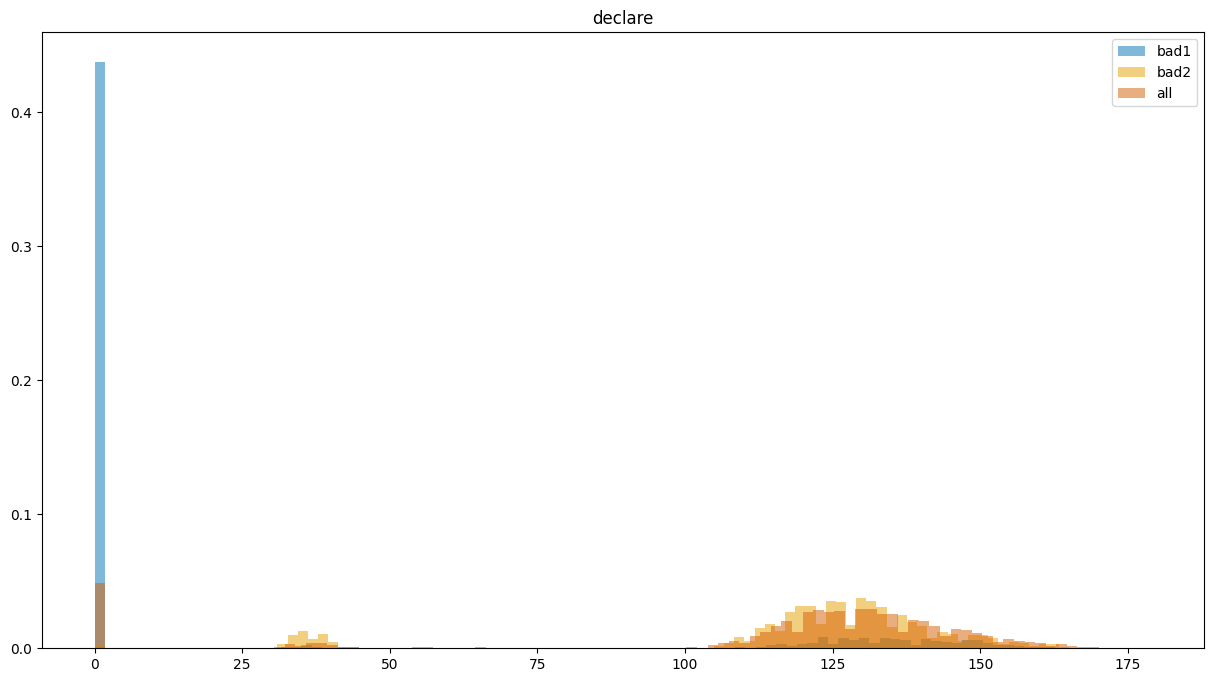

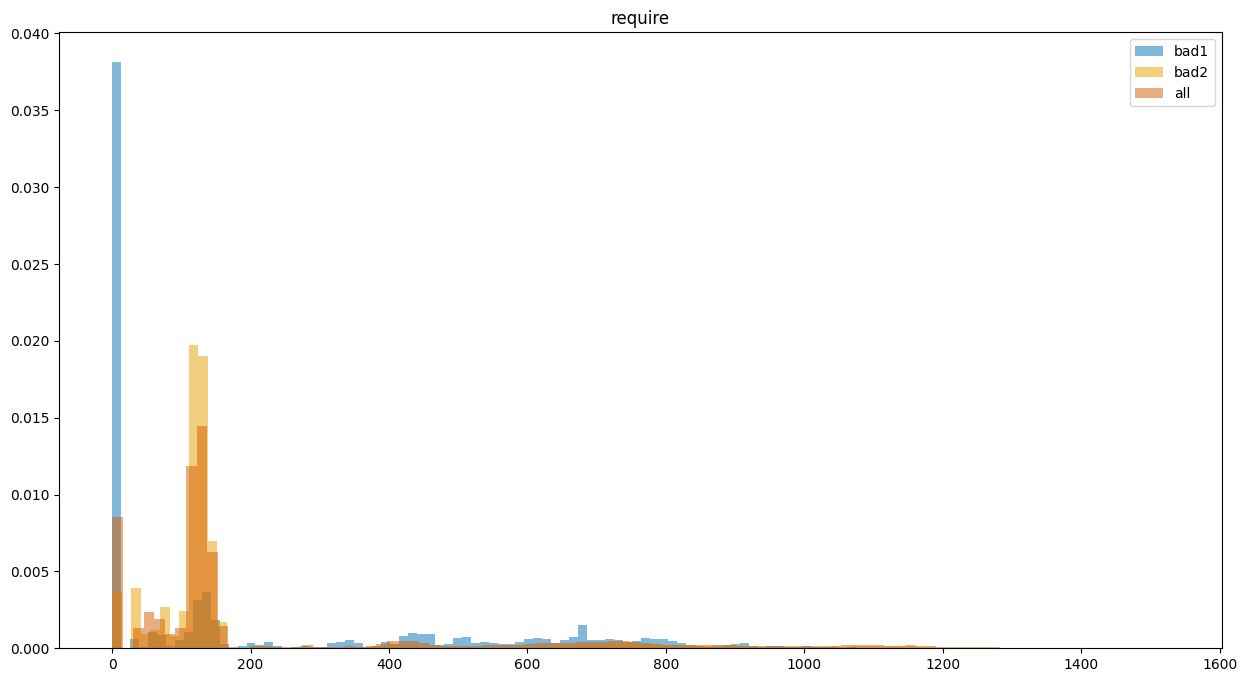

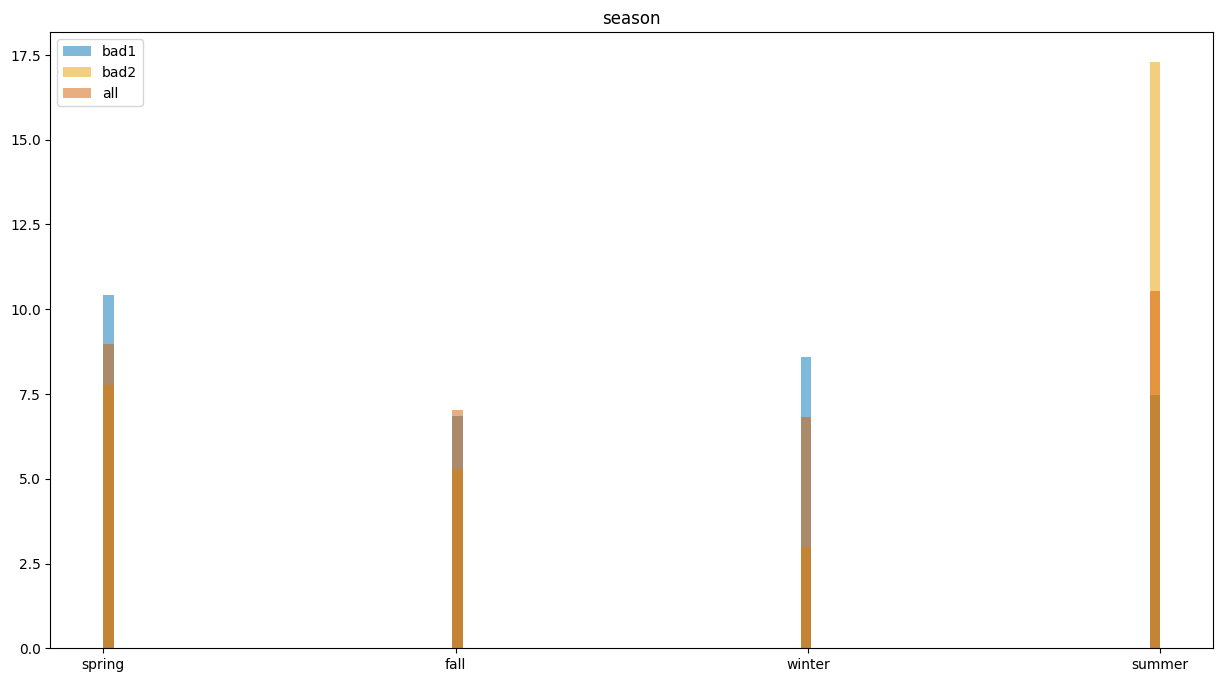

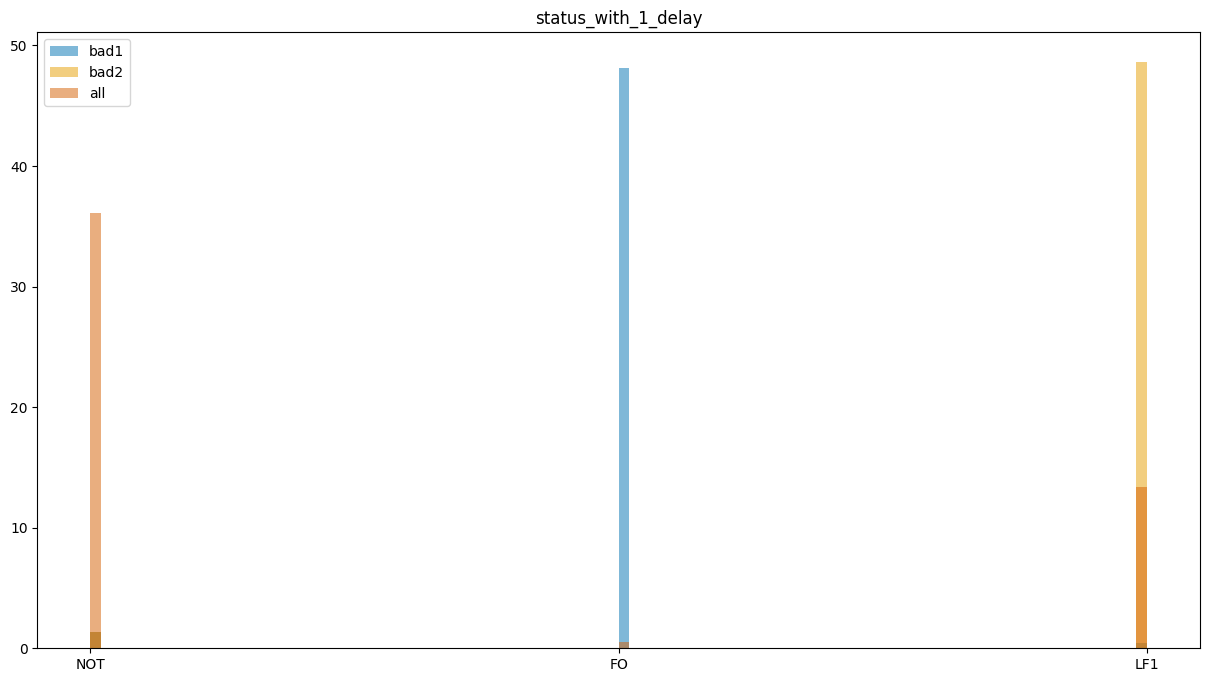

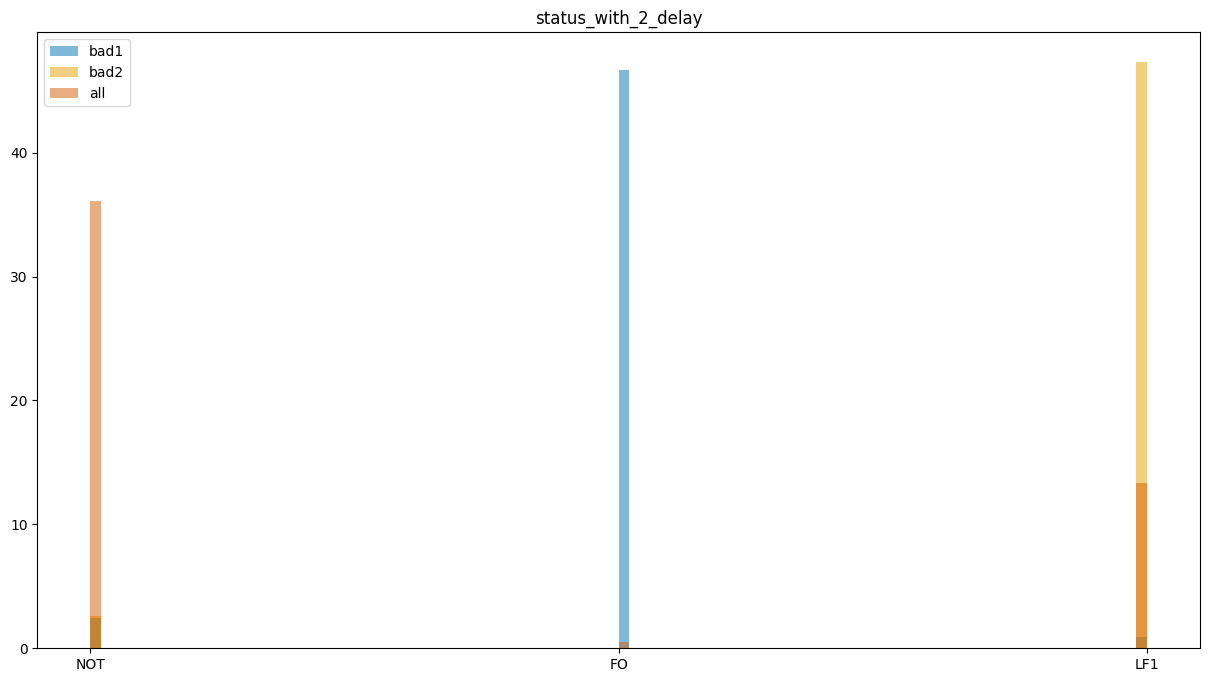

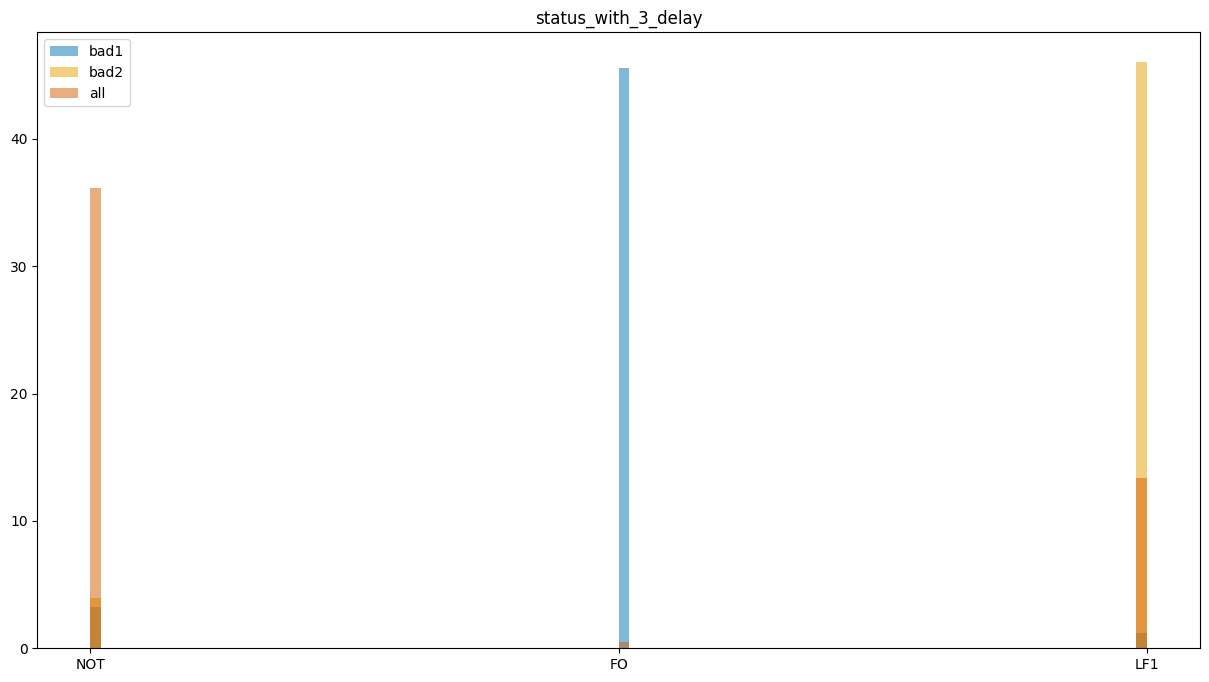

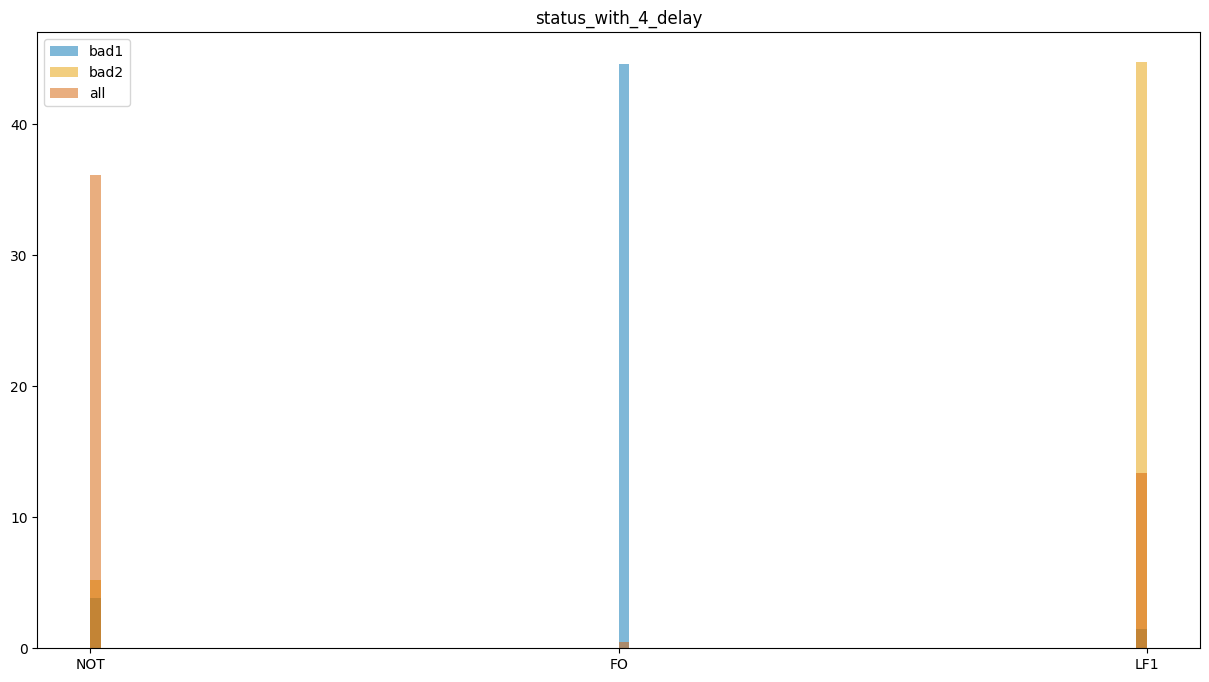

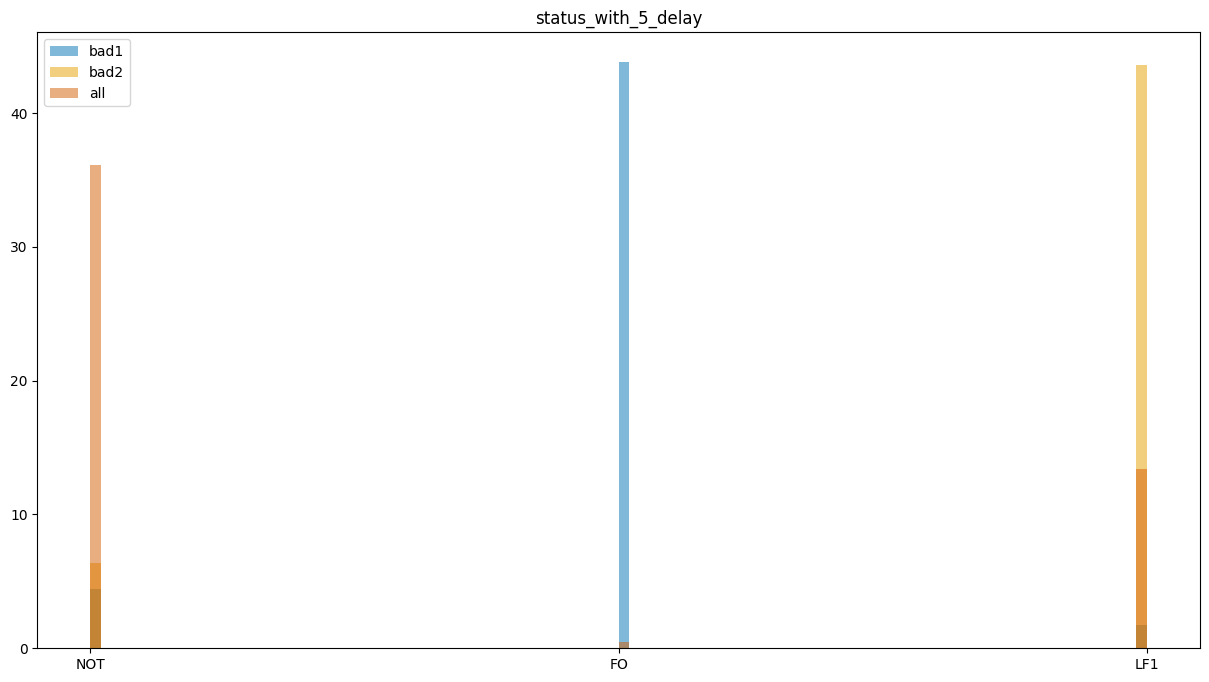

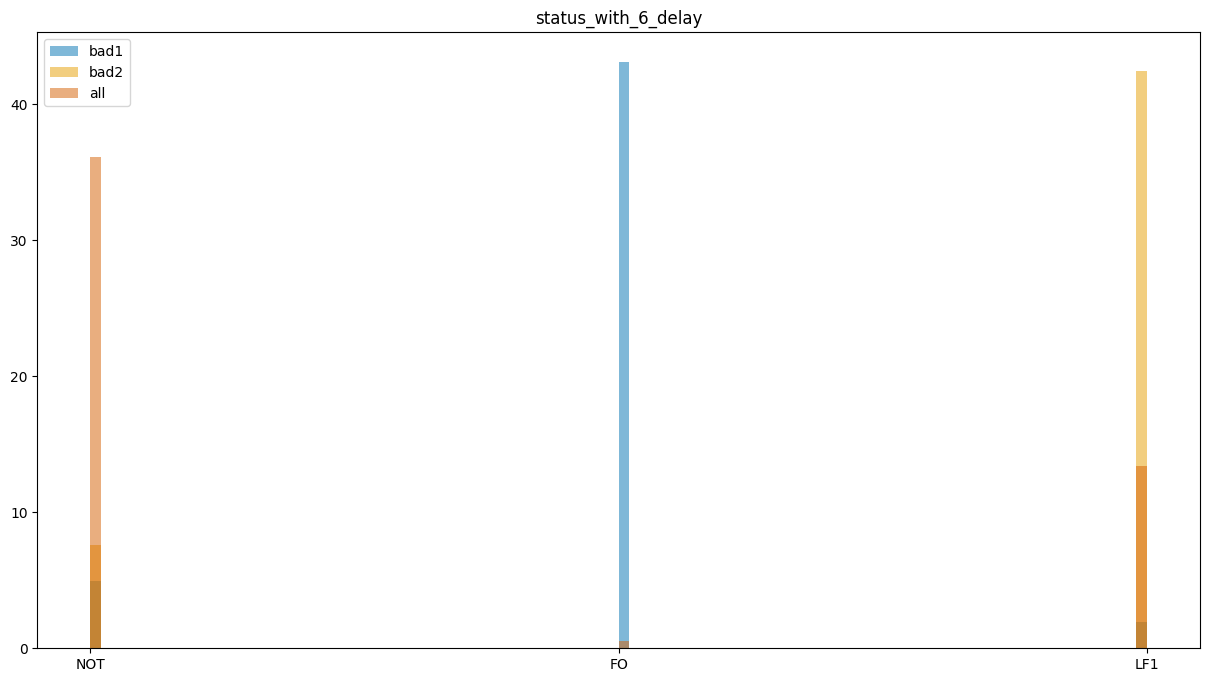

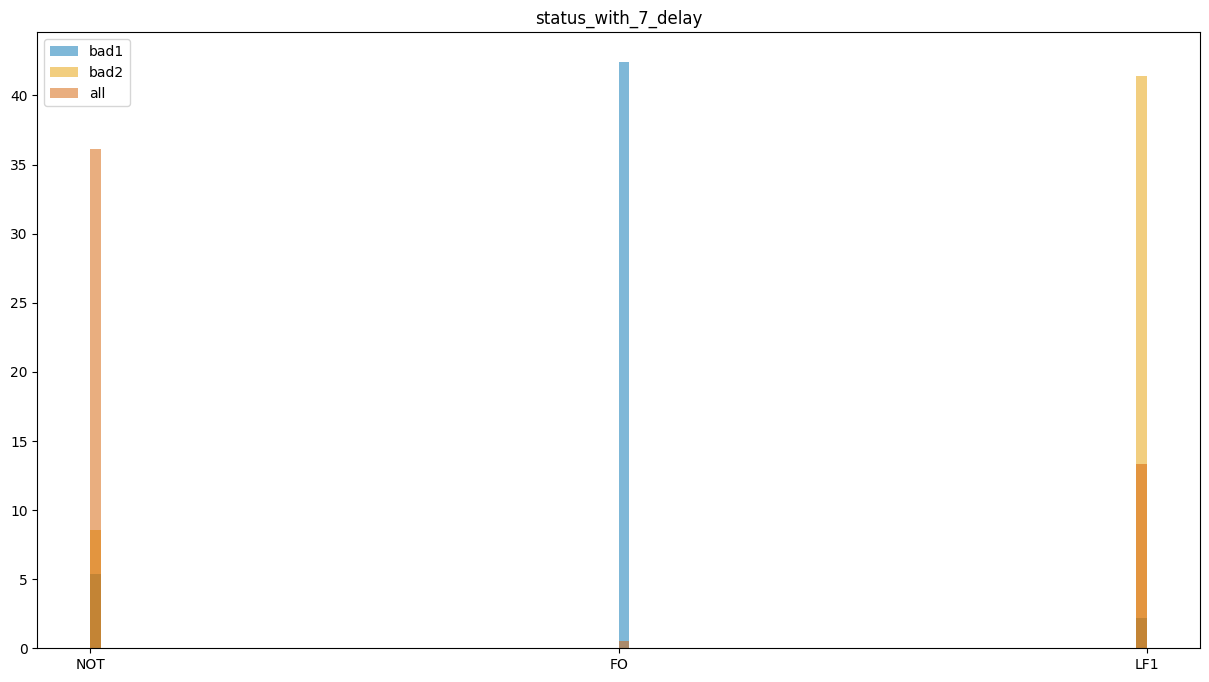

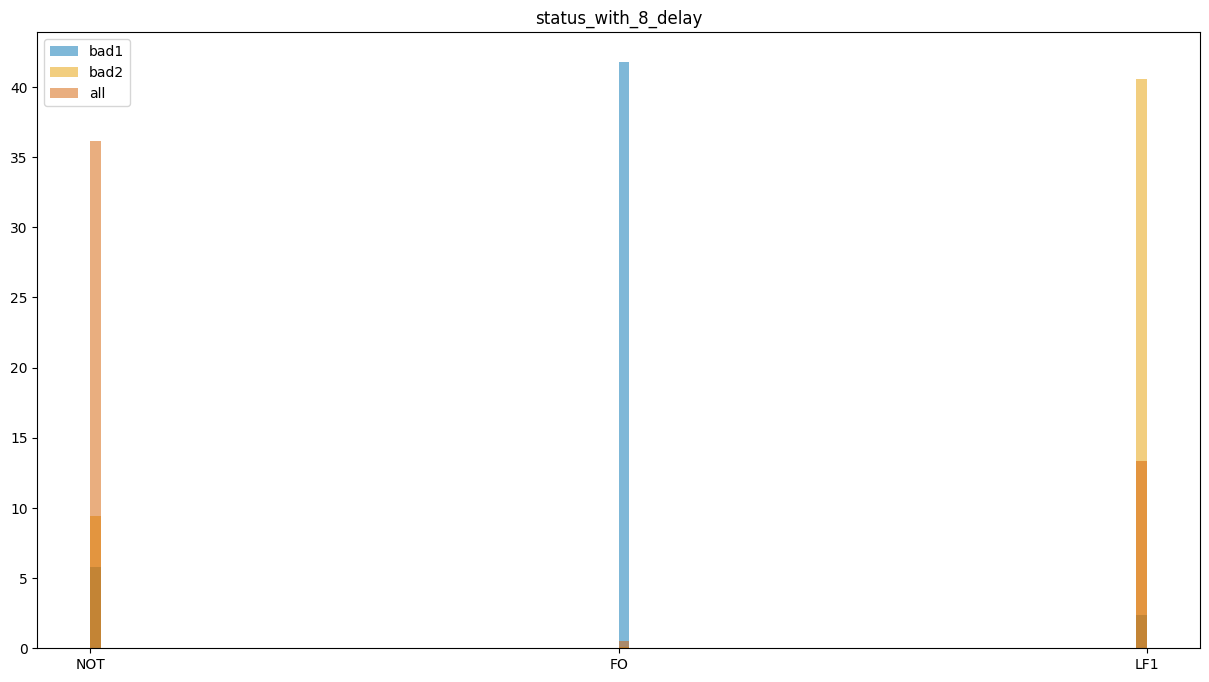

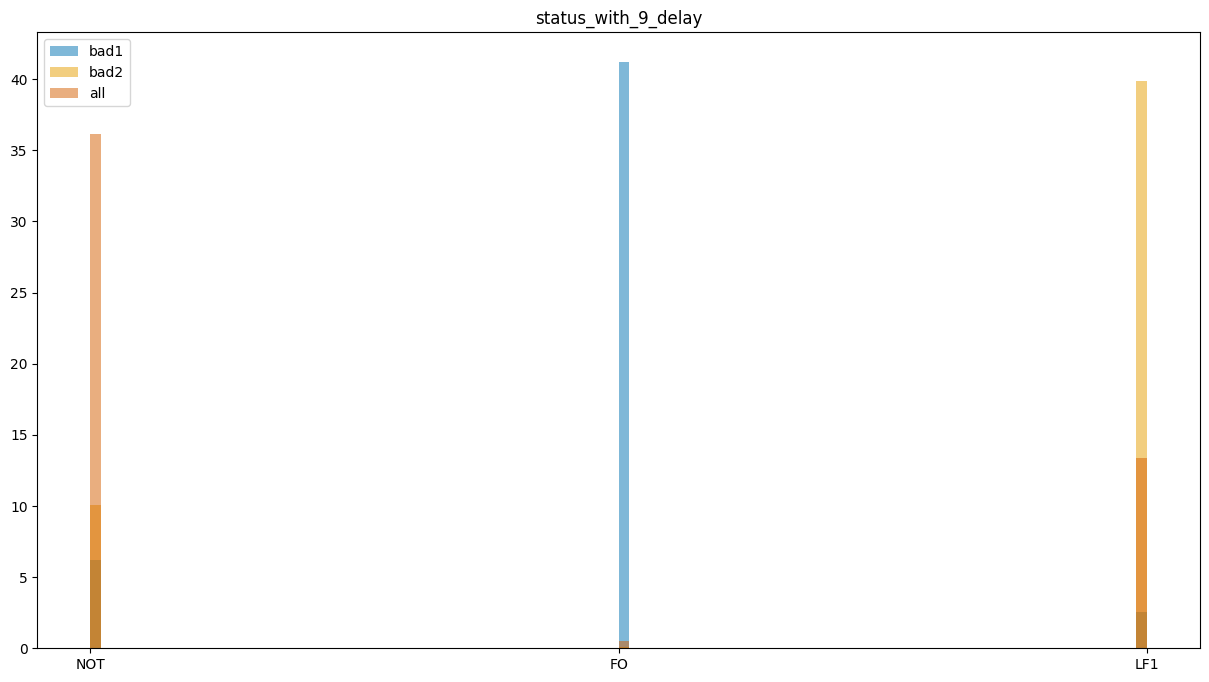

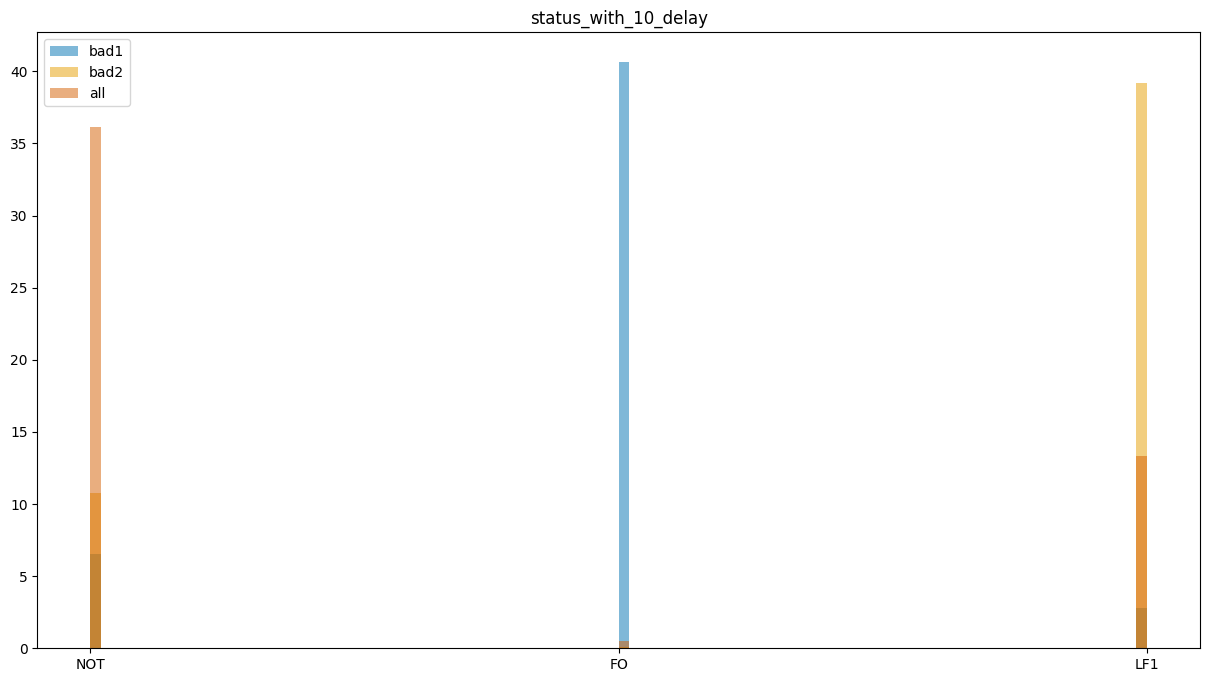

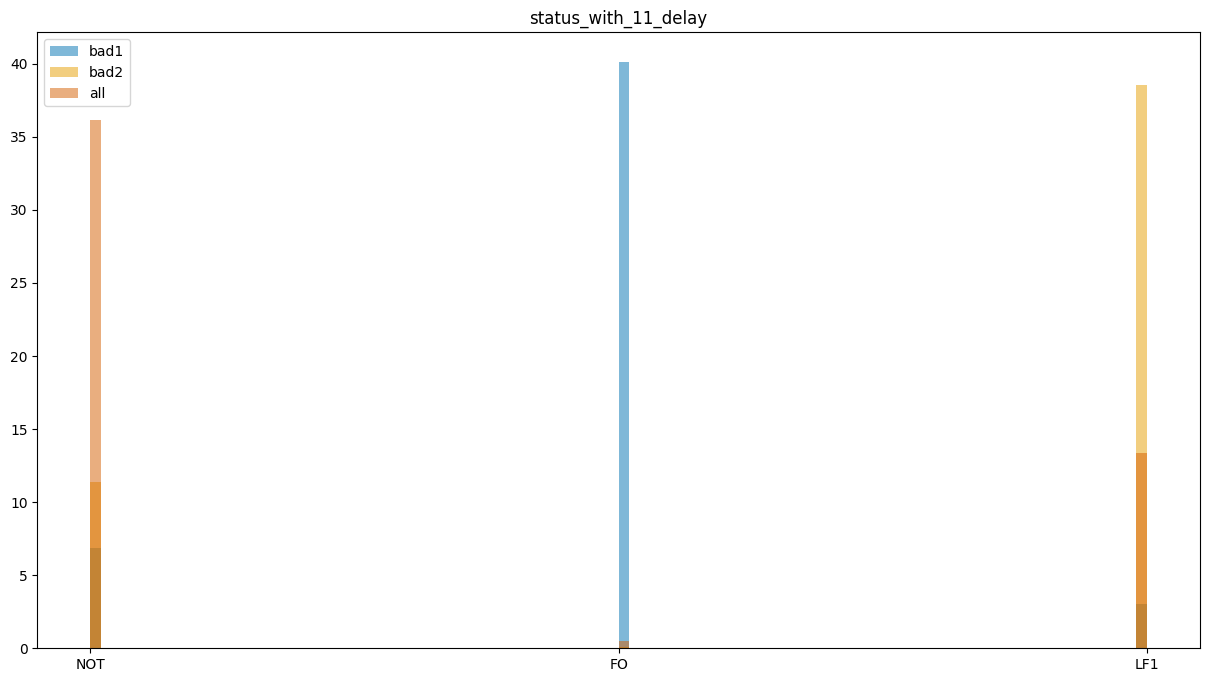

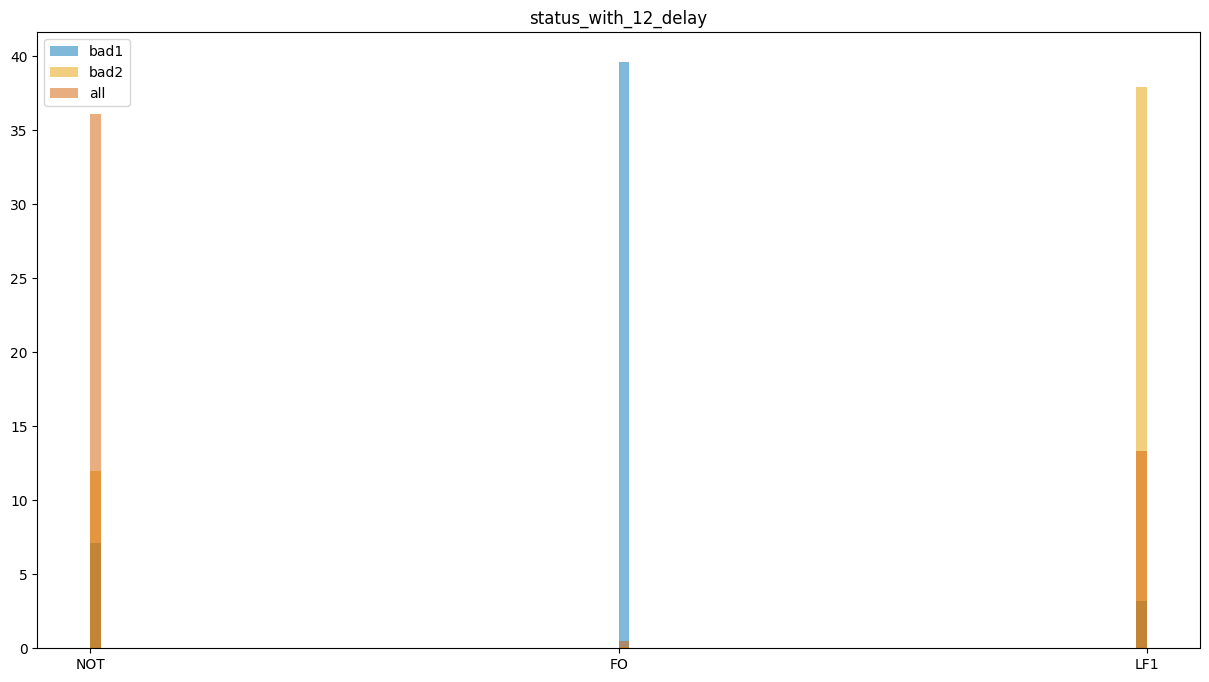

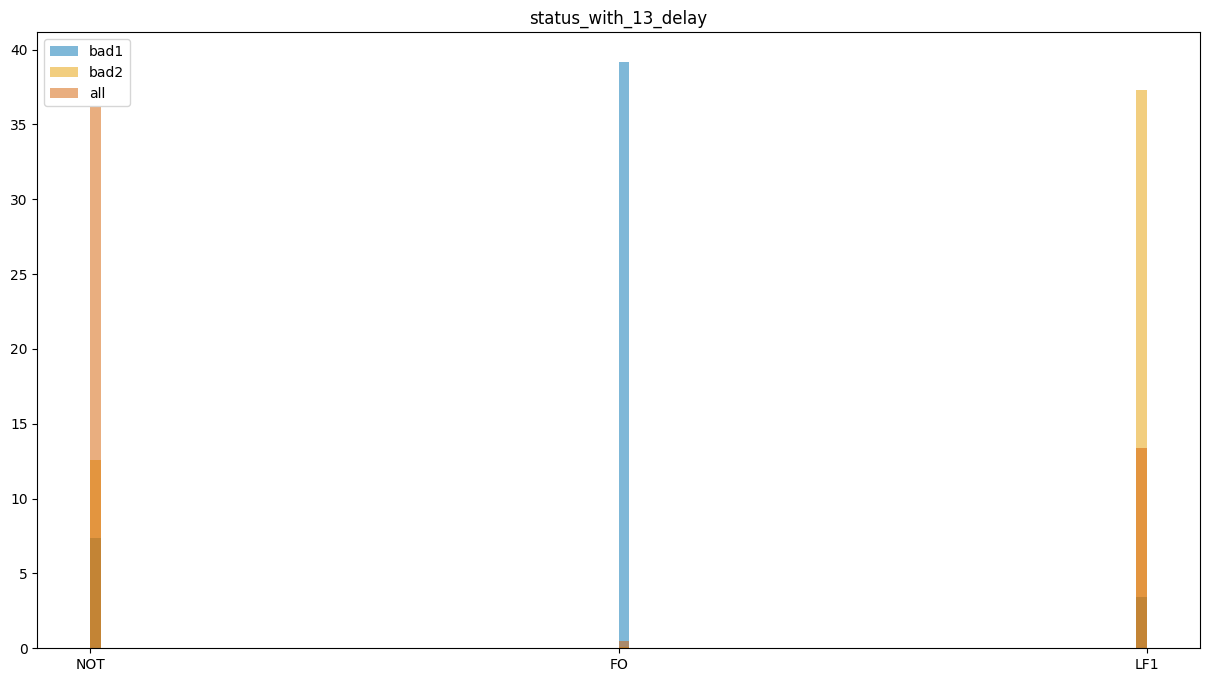

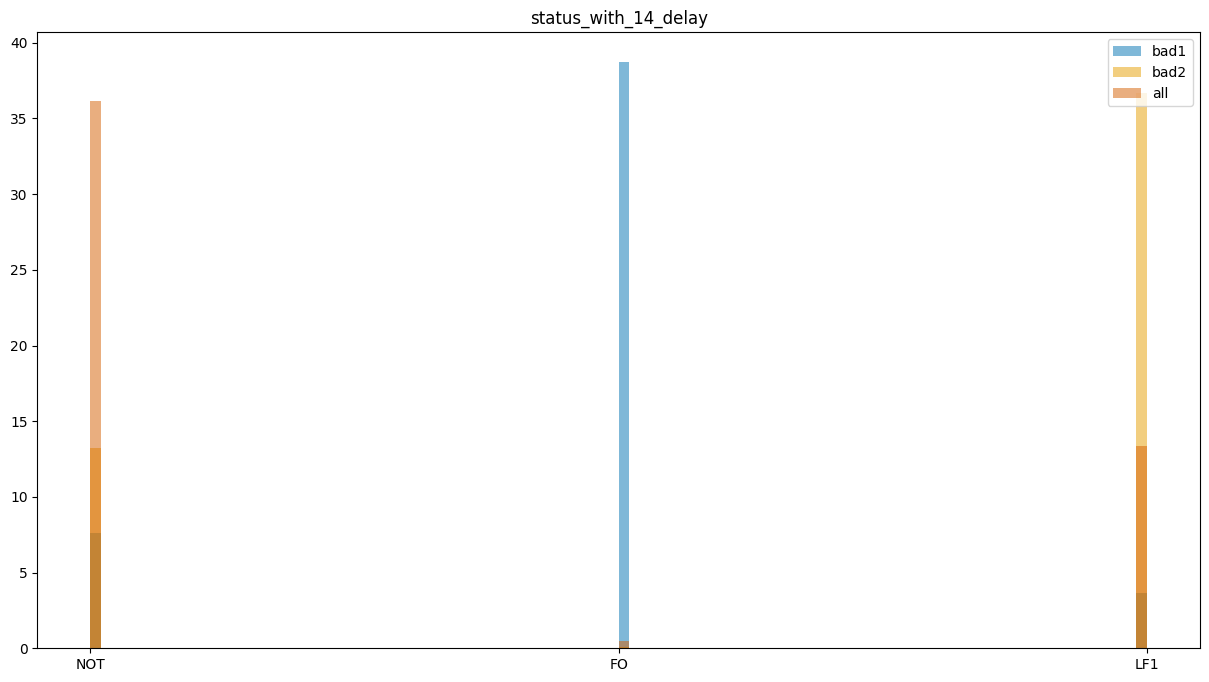

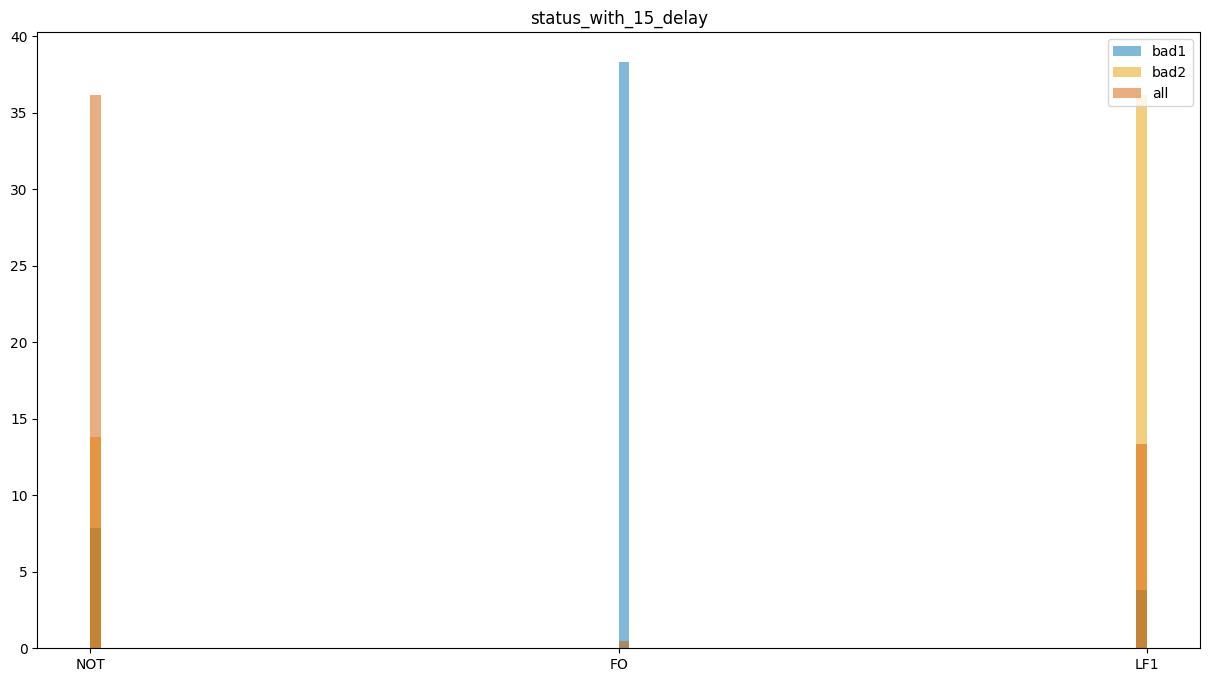

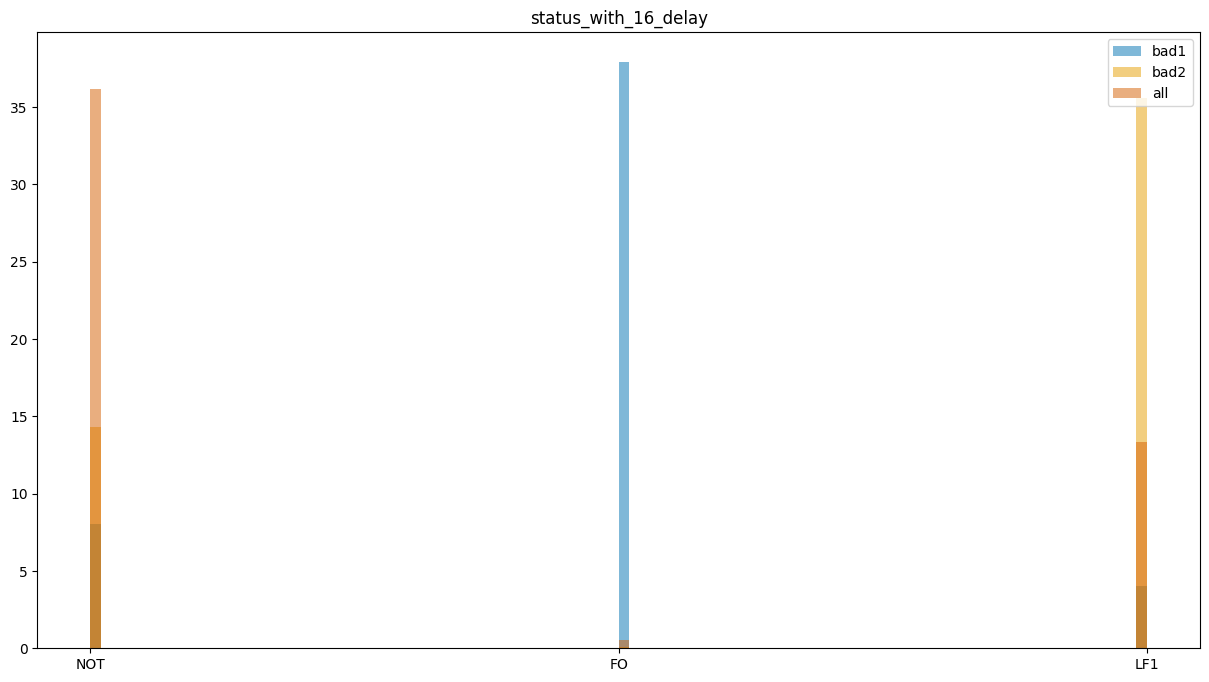

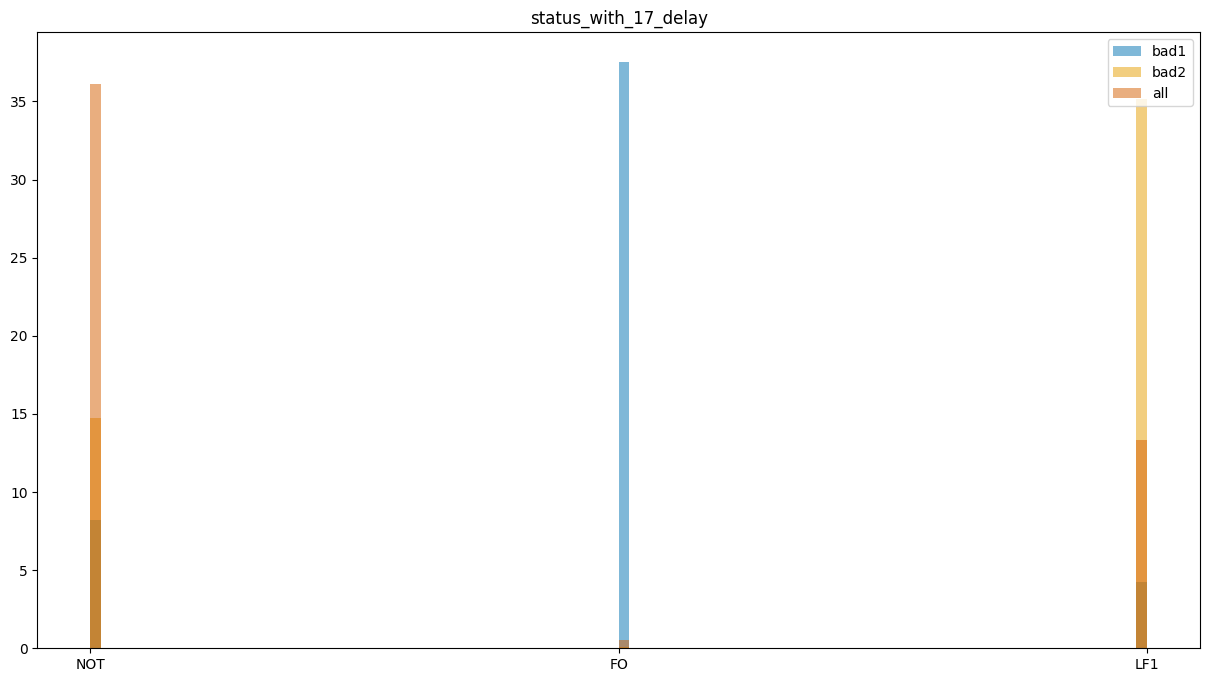

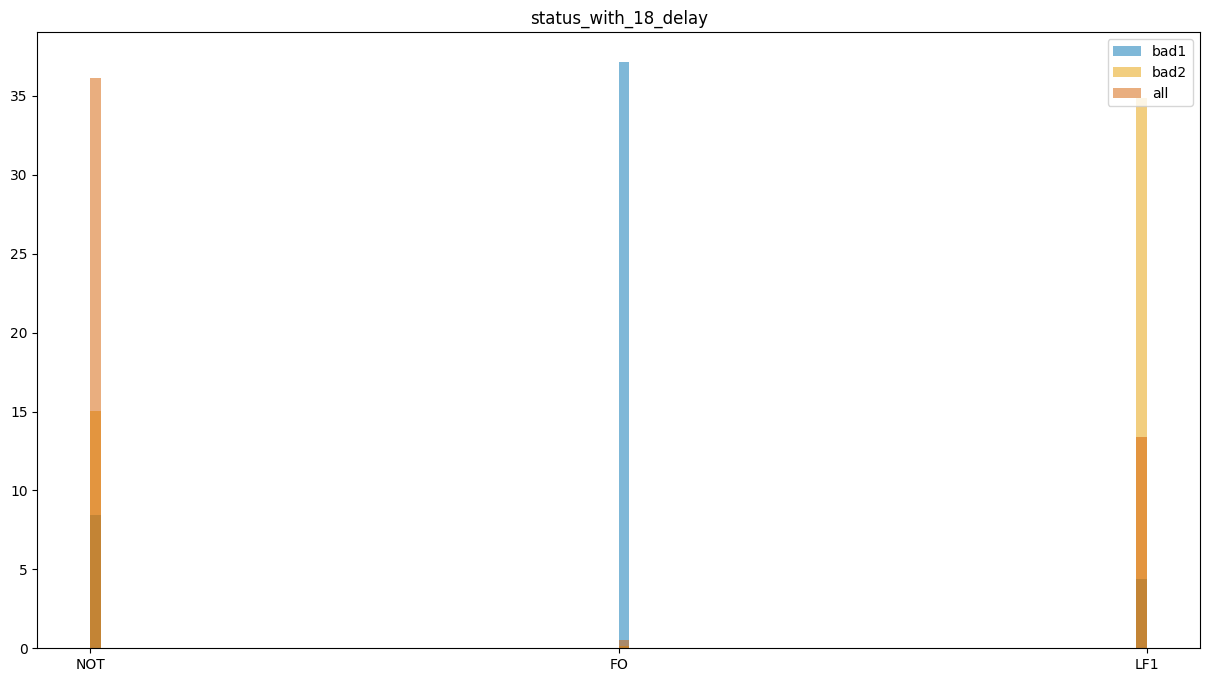

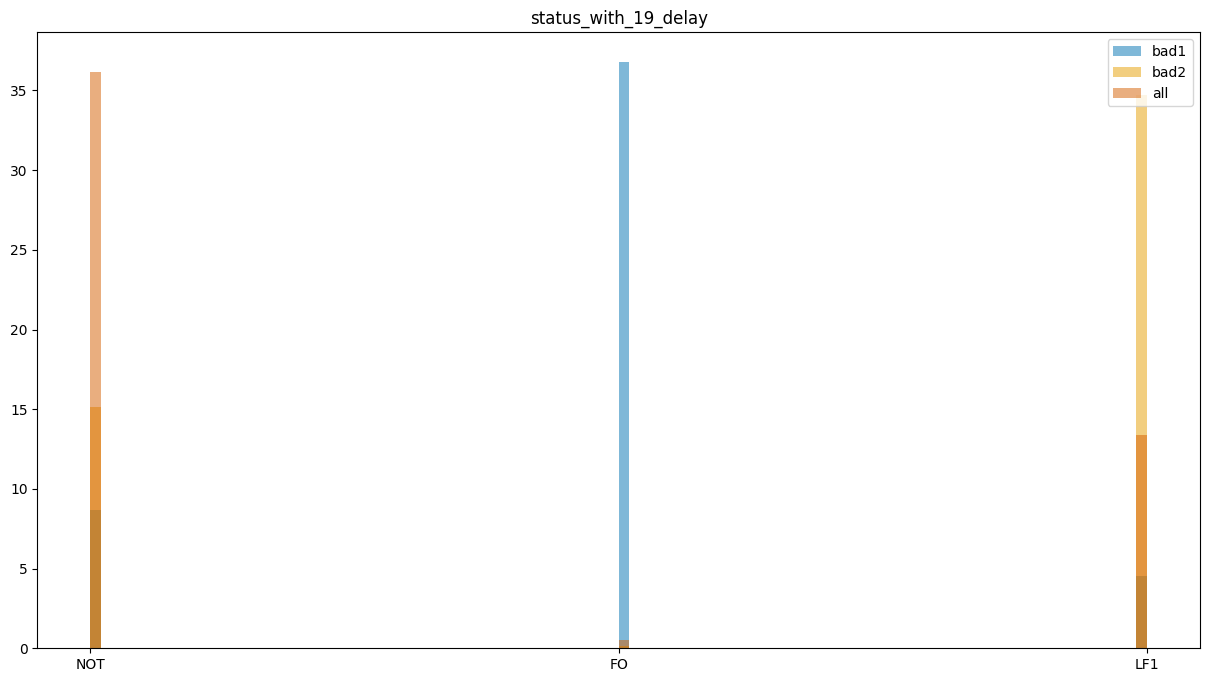

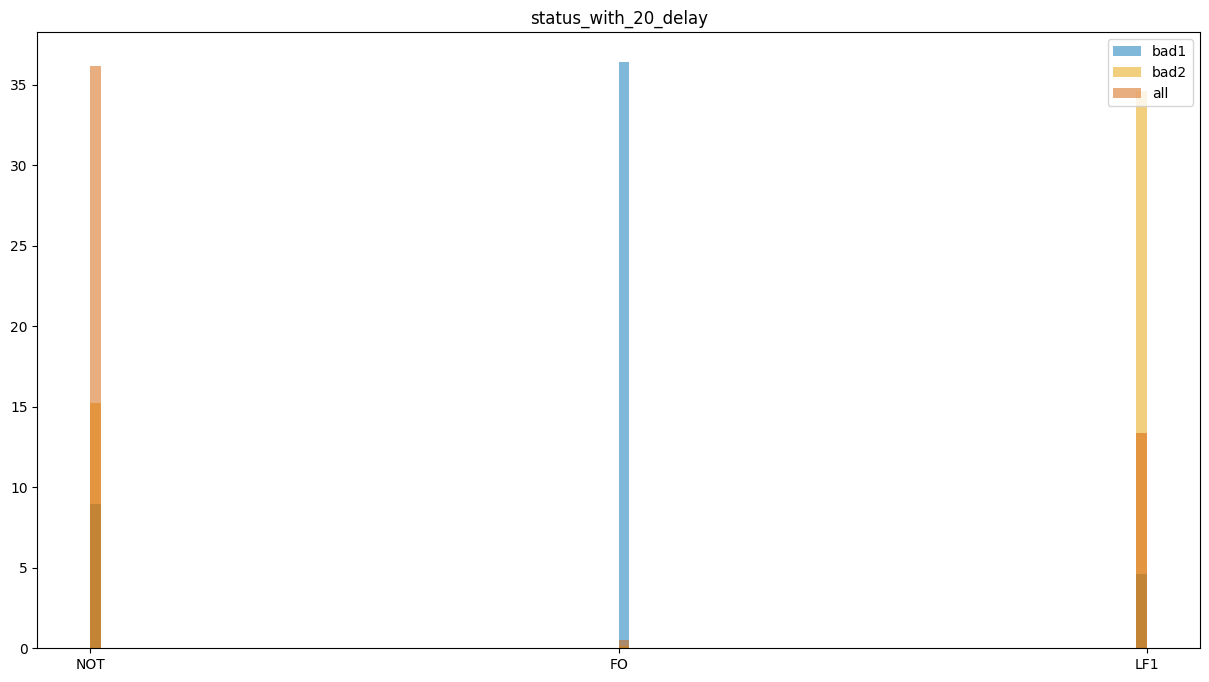

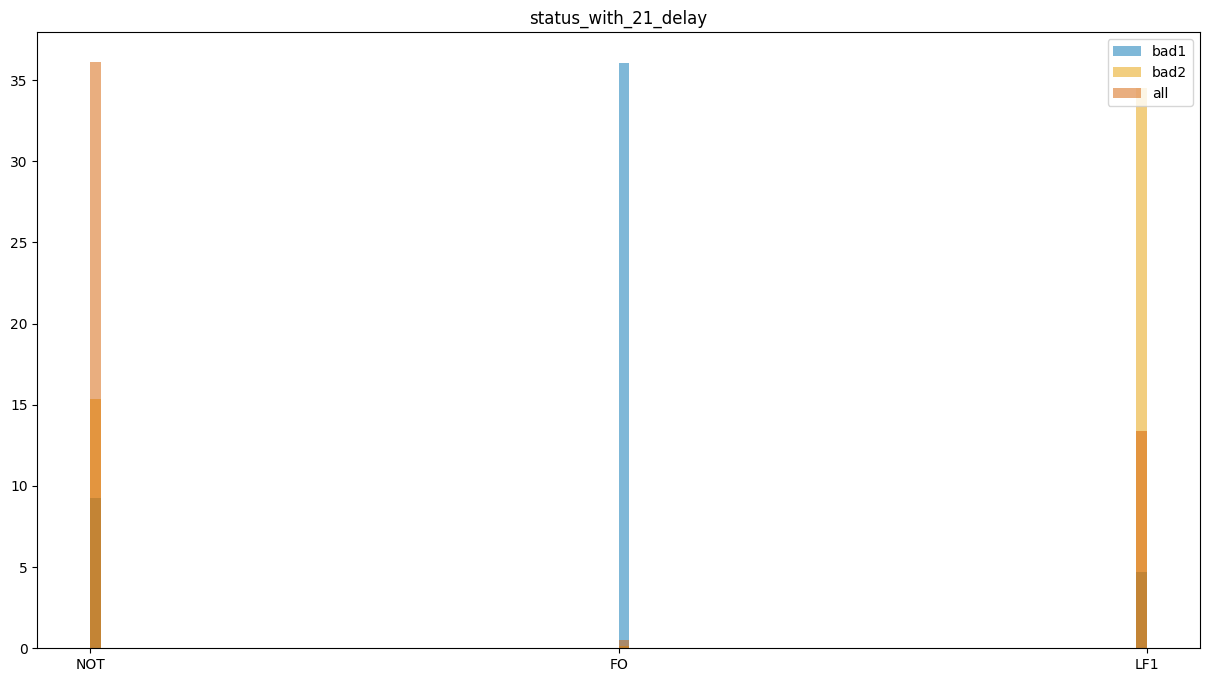

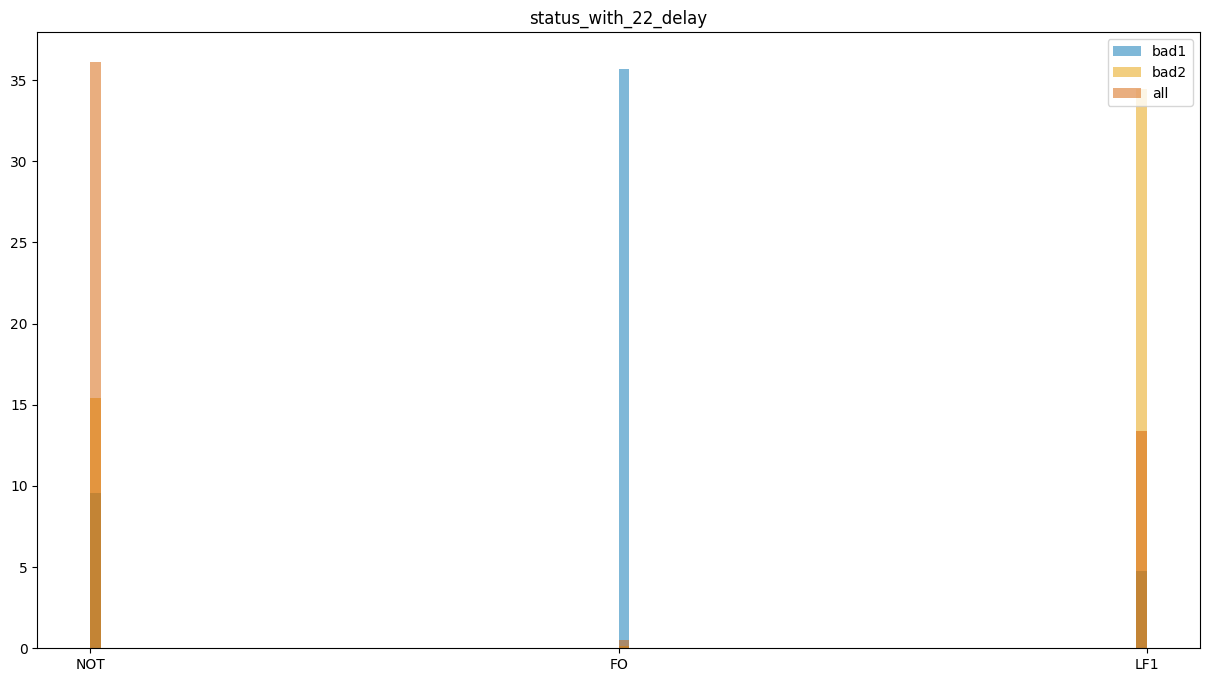

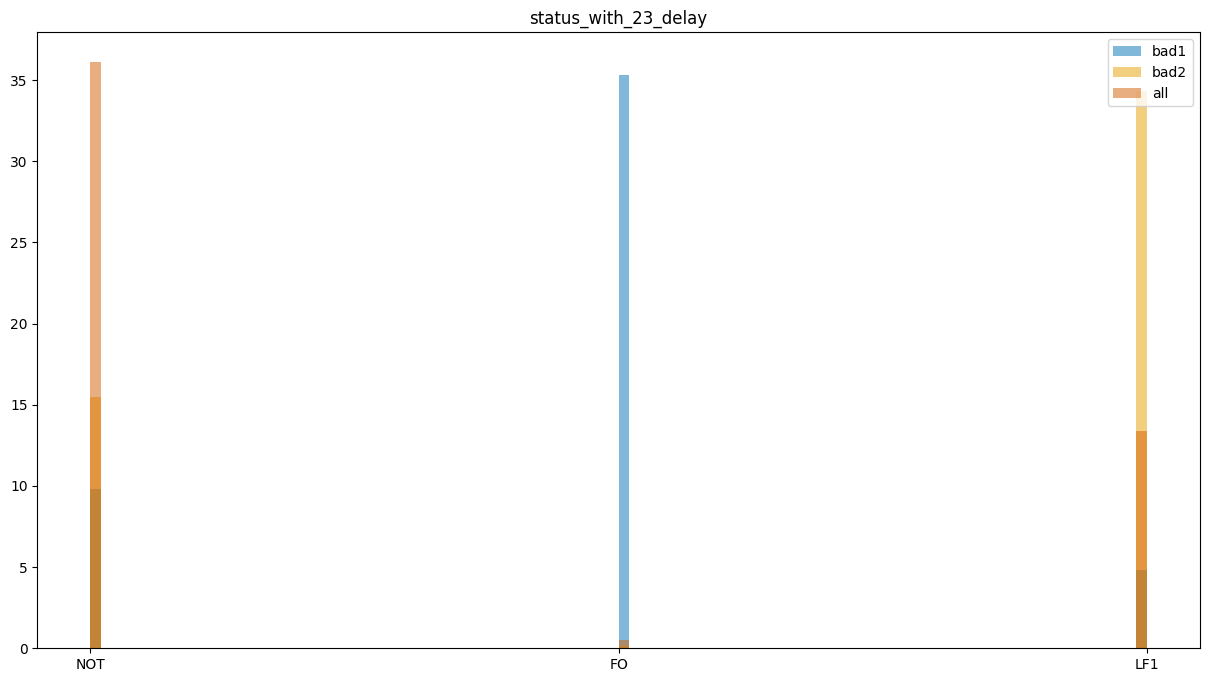

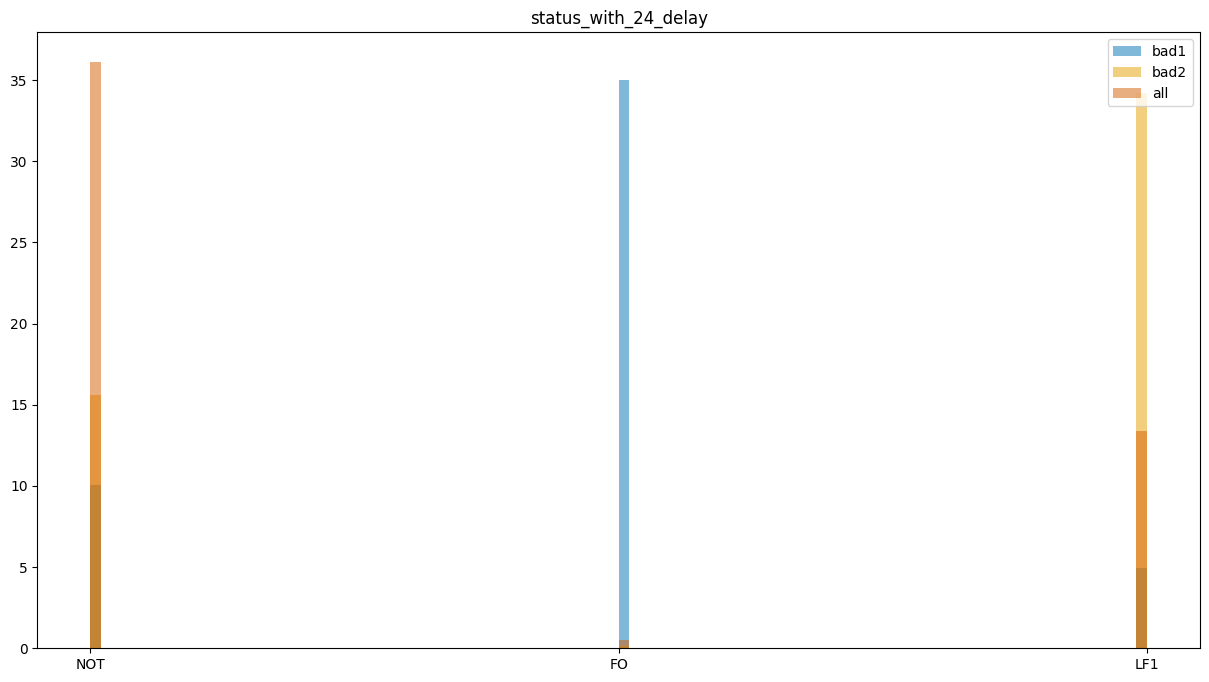

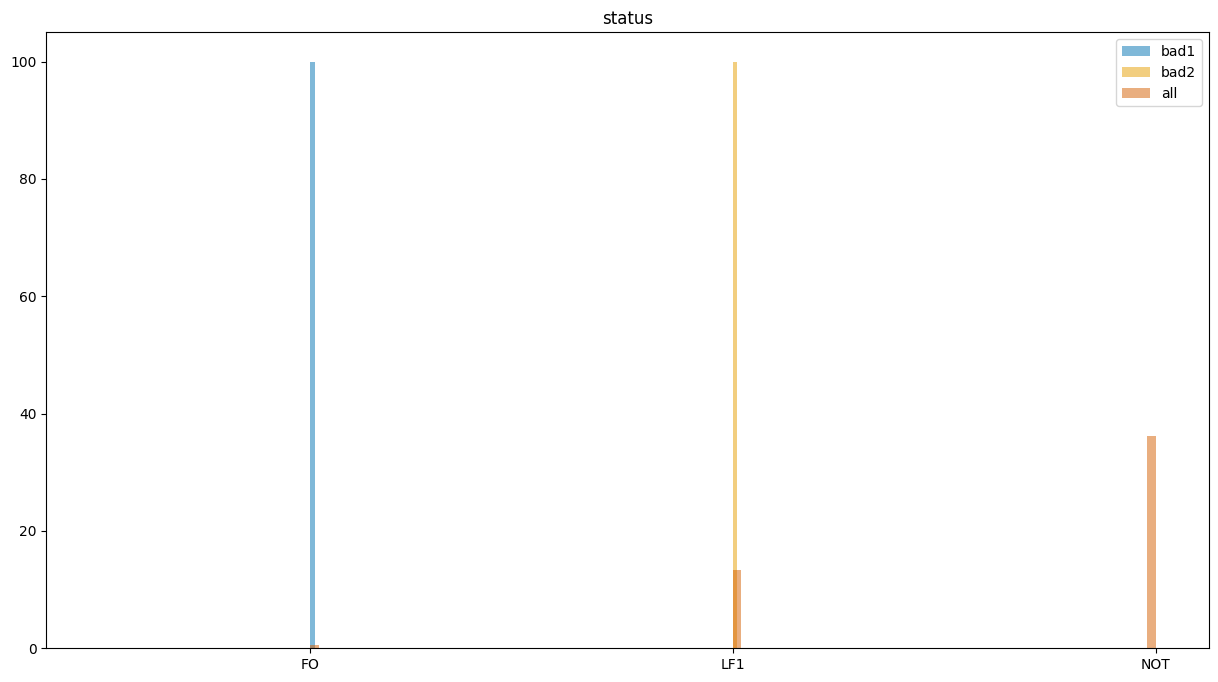

In [63]:
for col_name in df_modified.columns:
    compare_feature(col_name, 100)


In [68]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

for col in df_modified.select_dtypes(include="object"):
    df_modified[col] = df_modified[col].astype("category")

X, y = df_modified.drop(columns="status"), df_modified["status"]

mapping = {"FO": 0, "LF1": 1, "NOT": 2}
y_encoded = y.map(mapping)


X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, max_depth=10, use_label_encoder=False, eval_metric='logloss', enable_categorical=True)

model.fit(X_train, y_train)

y_pred = model.predict(X_train)

acc = accuracy_score(y_train, y_pred)
print("Train accuracy:", acc)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)


U:\ML_project\bargh\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:58:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train accuracy: 0.9938934120021259
Test accuracy: 0.9860368243326514
